# Olist E-Commerce Analysis
## Turning Transaction Data into Business Decisions

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Analyst:** Aman Singh  
**Objective:** Understand why 94% of customers never return and quantify the business impact

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.ticker as mticker
import os
import warnings

warnings.filterwarnings('ignore')

# Chart style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F8F8F8'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.family'] = 'DejaVu Sans'

os.makedirs('output', exist_ok = True)

## Layer 1 — Data Loading

In [2]:
orders = pd.read_csv('data/olist_orders_dataset.csv')
items = pd.read_csv('data/olist_order_items_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

print("Table shapes (rows, columns):")
print(f"  Orders:    {orders.shape}")
print(f"  Customers: {customers.shape}")
print(f"  Items:     {items.shape}")
print(f"  Reviews:   {reviews.shape}")

Table shapes (rows, columns):
  Orders:    (99441, 8)
  Customers: (99441, 5)
  Items:     (112650, 7)
  Reviews:   (99224, 7)


99,441 orders from 99,441 customers — meaning almost every customer placed exactly one order. 

112,650 items across 99,441 orders — meaning some orders had multiple items. Average is about 1.13 items per order.

99,224 reviews — almost every delivered order got a review.

## Layer 2 — Data Merging
Merging 4 tables into one master dataframe.

In [3]:
items_agg = items.groupby('order_id').agg(
    order_value   = ('price', 'sum'),
    freight_value = ('freight_value', 'sum'),
    n_items       = ('order_item_id', 'count')
).reset_index()


reviews_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()

In [4]:
df = (orders.merge(customers[['customer_id', 'customer_unique_id', 'customer_state']],on='customer_id', how='left')
      .merge(items_agg, on = 'order_id', how = 'left')
      .merge(reviews_agg, on = 'order_id', how = 'left')
     )

In [5]:
df.shape

(99441, 14)

In [6]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_state', 'order_value', 'freight_value',
       'n_items', 'review_score'],
      dtype='object')

In [7]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,order_value,freight_value,n_items,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,7c396fd4830fd04220f754e42b4e5bff,SP,29.99,8.72,1.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00,af07308b275d755c9edb36a90c618231,BA,118.70,22.76,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,159.90,19.22,1.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,18-11-2017 19:45,22-11-2017 13:39,02-12-2017 00:28,15-12-2017 00:00,7c142cf63193a1473d2e66489a9ae977,RN,45.00,27.20,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,13-02-2018 22:20,14-02-2018 19:46,16-02-2018 18:17,26-02-2018 00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP,19.90,8.72,1.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,09-03-2017 09:54,09-03-2017 09:54,10-03-2017 11:18,17-03-2017 15:08,28-03-2017 00:00,6359f309b166b0196dbf7ad2ac62bb5a,SP,72.00,13.08,1.0,5.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,06-02-2018 12:58,06-02-2018 13:10,07-02-2018 23:22,28-02-2018 17:37,02-03-2018 00:00,da62f9e57a76d978d02ab5362c509660,SP,174.90,20.10,1.0,4.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,27-08-2017 14:46,27-08-2017 15:04,28-08-2017 20:52,21-09-2017 11:24,27-09-2017 00:00,737520a9aad80b3fbbdad19b66b37b30,BA,205.99,65.02,1.0,5.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,08-01-2018 21:28,08-01-2018 21:36,12-01-2018 15:35,25-01-2018 23:32,15-02-2018 00:00,5097a5312c8b157bb7be58ae360ef43c,RJ,359.98,81.18,2.0,2.0


## Layer 3 — Data Cleaning & Feature Engineering

Cleaning steps:
1. Parse all date columns from string to datetime
2. Filter to delivered orders only
3. Engineer 4 new features: total_value, days_to_deliver, is_late, days_late

In [8]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%d-%m-%Y %H:%M')

In [9]:
df_clean = df[df['order_status'] == 'delivered'].copy()


print(f"All orders:       {len(df):,}")
print(f"Delivered orders: {len(df_clean):,}")
print(f"Dropped:          {len(df) - len(df_clean):,} non-delivered orders")

All orders:       99,441
Delivered orders: 96,478
Dropped:          2,963 non-delivered orders


In [10]:
df_clean['total_value']     = df_clean['order_value'] + df_clean['freight_value']
df_clean['days_to_deliver'] = (df_clean['order_delivered_customer_date'] -
                                df_clean['order_purchase_timestamp']).dt.days
df_clean['is_late']         = (df_clean['order_delivered_customer_date'] >
                                df_clean['order_estimated_delivery_date']).astype(int)
df_clean['days_late']       = (df_clean['order_delivered_customer_date'] -
                                df_clean['order_estimated_delivery_date']).dt.days.clip(lower=0)

print(f"\nNew features created:")
print(f"  Avg order value:      R${df_clean['total_value'].mean():.2f}")
print(f"  Avg days to deliver:  {df_clean['days_to_deliver'].mean():.1f} days")
print(f"  Late deliveries:      {df_clean['is_late'].sum():,} ({df_clean['is_late'].mean()*100:.1f}%)")


New features created:
  Avg order value:      R$159.83
  Avg days to deliver:  12.1 days
  Late deliveries:      7,826 (8.1%)


### Null Check & Final Clean
Checking for missing values in key columns before analysis begins.

In [11]:
key_cols = ['total_value', 'days_to_deliver', 'is_late',
            'review_score', 'customer_unique_id', 'customer_state']

print("Null counts in key columns:")
print(df_clean[key_cols].isnull().sum().to_string())

# Drop rows missing total_value or days_to_deliver
before = len(df_clean)
df_clean = df_clean.dropna(subset=['total_value', 'days_to_deliver'])
after = len(df_clean)

print(f"\nRows before null drop: {before:,}")
print(f"Rows after null drop:  {after:,}")
print(f"Dropped:               {before - after:,} rows")
print(f"\nFinal clean dataset:   {after:,} delivered orders ready for analysis")

Null counts in key columns:
total_value             0
days_to_deliver         8
is_late                 0
review_score          646
customer_unique_id      0
customer_state          0

Rows before null drop: 96,478
Rows after null drop:  96,470
Dropped:               8 rows

Final clean dataset:   96,470 delivered orders ready for analysis


## Analysis 1 — Customer Journey Funnel
**Business Question:** What percentage of customers return after their first purchase?

This is the headline finding of the entire project.
Key: using customer_unique_id (not customer_id) because Olist assigns
a new customer_id per order — customer_unique_id tracks the same person.

In [12]:
# Count orders per unique customer
customer_orders = (df_clean
                   .groupby('customer_unique_id')
                   .agg(
                       total_orders    = ('order_id', 'count'),
                       first_purchase  = ('order_purchase_timestamp', 'min'),
                       last_purchase   = ('order_purchase_timestamp', 'max'),
                       total_spent     = ('total_value', 'sum'),
                       avg_review      = ('review_score', 'mean'),
                       late_rate       = ('is_late', 'mean')
                   )
                   .reset_index())

total_customers   = len(customer_orders)
returned_2nd      = (customer_orders['total_orders'] >= 2).sum()
returned_3rd      = (customer_orders['total_orders'] >= 3).sum()
loyal             = (customer_orders['total_orders'] >= 4).sum()
never_returned    = total_customers - returned_2nd
never_return_pct  = never_returned / total_customers * 100



print("=" * 45)
print("  CUSTOMER JOURNEY FUNNEL")
print("=" * 45)
print(f"  Total unique customers:   {total_customers:,}")
print(f"  Made 2nd purchase:        {returned_2nd:,}  ({returned_2nd/total_customers*100:.1f}%)")
print(f"  Made 3rd purchase:        {returned_3rd:,}  ({returned_3rd/total_customers*100:.1f}%)")
print(f"  Loyal (4+ purchases):     {loyal:,}  ({loyal/total_customers*100:.1f}%)")
print(f"\n  Never returned:           {never_returned:,}  ({never_return_pct:.1f}%)")
print("=" * 45)
print(f"\n  KEY FINDING: {never_return_pct:.1f}% of customers")
print(f"  never make a second purchase.")

  CUSTOMER JOURNEY FUNNEL
  Total unique customers:   93,350
  Made 2nd purchase:        2,801  (3.0%)
  Made 3rd purchase:        228  (0.2%)
  Loyal (4+ purchases):     47  (0.1%)

  Never returned:           90,549  (97.0%)

  KEY FINDING: 97.0% of customers
  never make a second purchase.


### Funnel Visualisation

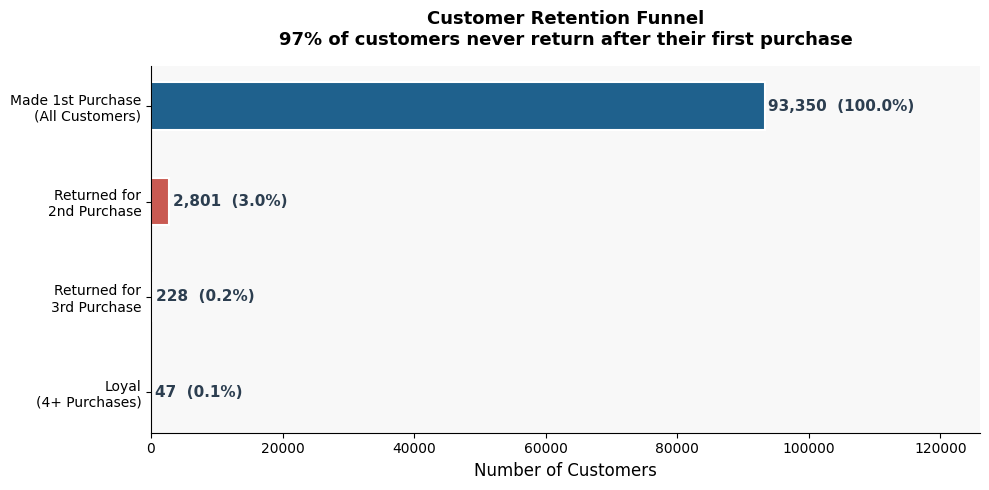

Chart saved to outputs/01_customer_funnel.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

stages = [
    'Made 1st Purchase\n(All Customers)',
    'Returned for\n2nd Purchase',
    'Returned for\n3rd Purchase',
    'Loyal\n(4+ Purchases)'
]

counts = [
    total_customers,
    returned_2nd,
    returned_3rd,
    loyal
]

colors = ['#1F618D', '#C95A52', '#1F618D', '#1F618D']

bars = ax.barh(
    stages,
    counts,
    color=colors,
    height=0.5,
    edgecolor='white',
    linewidth=1.5
)

for bar, count in zip(bars, counts):
    pct = count / total_customers * 100

    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,}  ({pct:.1f}%)',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='#2C3E50'
    )

ax.set_xlabel(
    'Number of Customers',
    fontsize=12
)

ax.set_title(
    'Customer Retention Funnel\n97% of customers never return after their first purchase',
    fontsize=13,
    fontweight='bold',
    pad=15
)

ax.set_xlim(
    0,
    total_customers * 1.35
)

ax.invert_yaxis()

ax.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    'outputs/01_customer_funnel.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Chart saved to outputs/01_customer_funnel.png")

## Analysis 2 — Sales Trend Analysis
**Business Question:** How does revenue trend over time and when do customers buy most?

Extracting time-based features to understand purchasing patterns.

In [14]:
# Extract time features
df_clean['purchase_month']   = df_clean['order_purchase_timestamp'].dt.to_period('M')
df_clean['purchase_year']    = df_clean['order_purchase_timestamp'].dt.year
df_clean['day_of_week']      = df_clean['order_purchase_timestamp'].dt.day_name()

# Monthly revenue — filter to 2017-2018 for clean trend
monthly_revenue = (df_clean[df_clean['purchase_year'].isin([2017, 2018])]
                   .groupby('purchase_month')['total_value']
                   .sum()
                   .reset_index())
monthly_revenue['purchase_month'] = monthly_revenue['purchase_month'].astype(str)

# Day of week revenue
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_revenue = (df_clean
               .groupby('day_of_week')['total_value']
               .sum()
               .reindex(day_order)
               .reset_index())

print("Monthly Revenue (2017-2018):")
print(monthly_revenue.to_string(index=False))
print(f"\nBest month:  {monthly_revenue.loc[monthly_revenue['total_value'].idxmax(), 'purchase_month']}")
print(f"Worst month: {monthly_revenue.loc[monthly_revenue['total_value'].idxmin(), 'purchase_month']}")
print(f"\nRevenue by Day of Week:")
print(dow_revenue.to_string(index=False))

Monthly Revenue (2017-2018):
purchase_month  total_value
       2017-01    127482.37
       2017-02    271239.32
       2017-03    414330.95
       2017-04    390812.40
       2017-05    566657.40
       2017-06    490050.37
       2017-07    566299.08
       2017-08    645832.36
       2017-09    701077.49
       2017-10    751117.01
       2017-11   1153229.37
       2017-12    843078.29
       2018-01   1077887.46
       2018-02    966168.41
       2018-03   1120598.24
       2018-04   1132878.93
       2018-05   1128774.52
       2018-06   1011448.96
       2018-07   1027286.52
       2018-08    985491.64

Best month:  2017-11
Worst month: 2017-01

Revenue by Day of Week:
day_of_week  total_value
     Monday   2530094.03
    Tuesday   2473553.80
  Wednesday   2395846.33
   Thursday   2283677.03
     Friday   2222323.03
   Saturday   1705802.70
     Sunday   1807097.91


### Sales Trend Visualisation

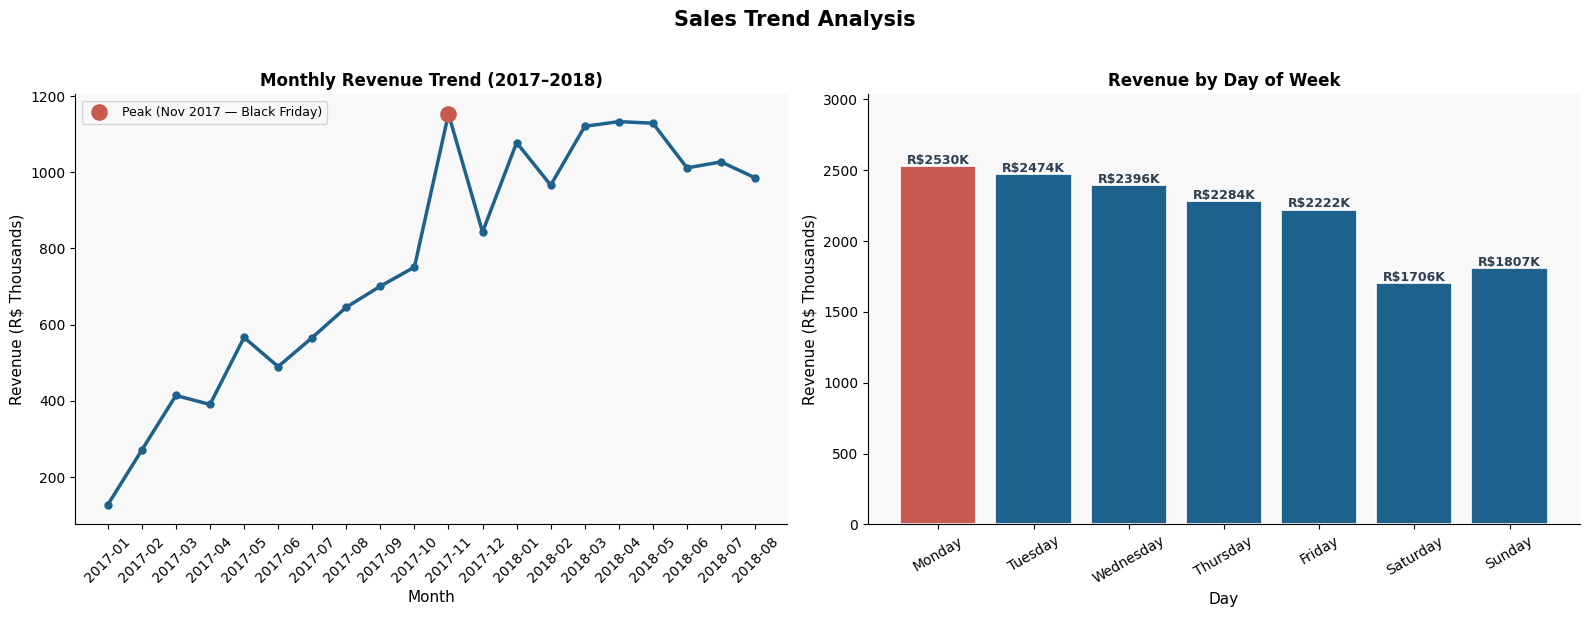

Chart saved to outputs/02_sales_trend.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sales Trend Analysis', fontsize=15, fontweight='bold', y=1.02)

ax1 = axes[0]
ax1.plot(monthly_revenue['purchase_month'],
         monthly_revenue['total_value'] / 1000,
         color='#1F618D', linewidth=2.5, marker='o', markersize=5)

peak_idx = monthly_revenue['total_value'].idxmax()
ax1.scatter(monthly_revenue.loc[peak_idx, 'purchase_month'],
            monthly_revenue.loc[peak_idx, 'total_value'] / 1000,
            color='#C95A52', s=120, zorder=5, label='Peak (Nov 2017 — Black Friday)')

ax1.set_title('Monthly Revenue Trend (2017–2018)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Revenue (R$ Thousands)', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(False)

ax2 = axes[1]
bar_colors = ['#1F618D' if day != 'Monday' else '#C95A52'
              for day in dow_revenue['day_of_week']]

bars = ax2.bar(dow_revenue['day_of_week'],
               dow_revenue['total_value'] / 1000,
               color=bar_colors, edgecolor='white', linewidth=1.2)

for bar in bars:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 15,
             f"R${bar.get_height():.0f}K",
             ha='center', fontsize=9, fontweight='bold', color='#2C3E50')

ax2.set_title('Revenue by Day of Week', fontsize=12, fontweight='bold')
ax2.set_xlabel('Day', fontsize=11)
ax2.set_ylabel('Revenue (R$ Thousands)', fontsize=11)
ax2.set_ylim(0, dow_revenue['total_value'].max() / 1000 * 1.2)
ax2.tick_params(axis='x', rotation=30)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(False)

plt.tight_layout()
plt.savefig('outputs/02_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/02_sales_trend.png")

## Analysis 3 — Delivery Impact Analysis
**Business Question:** Do late deliveries cause bad reviews and prevent customers from returning?

**Hypothesis:** Late delivery → bad review → customer never returns
Testing this chain with data.

In [16]:
# ── STEP 1: Late delivery vs Review Score ─────────────────────────────────
review_by_lateness = (df_clean
                      .groupby('is_late')['review_score']
                      .agg(['mean', 'count'])
                      .reset_index())
review_by_lateness['is_late'] = review_by_lateness['is_late'].map({0: 'On Time', 1: 'Late'})
review_by_lateness.columns    = ['Delivery Status', 'Avg Review Score', 'Order Count']

print("Review Score by Delivery Status:")
print(review_by_lateness.to_string(index=False))

ontime_score = review_by_lateness.loc[review_by_lateness['Delivery Status']=='On Time', 'Avg Review Score'].values[0]
late_score   = review_by_lateness.loc[review_by_lateness['Delivery Status']=='Late',    'Avg Review Score'].values[0]
print(f"\nDrop in review score due to late delivery: {ontime_score - late_score:.2f} points")
print(f"That is a {(ontime_score - late_score)/ontime_score*100:.1f}% drop in satisfaction")

# ── STEP 2: Does first-order experience predict return? ───────────────────
# Get each customer's first order details
first_orders = (df_clean
                .sort_values('order_purchase_timestamp')
                .groupby('customer_unique_id')
                .first()
                .reset_index()
                [['customer_unique_id', 'is_late', 'review_score', 'days_to_deliver']])

# Merge with customer_orders (has total_orders = whether they returned)
customer_exp = customer_orders.merge(first_orders, on='customer_unique_id', how='left')
customer_exp['returned'] = (customer_exp['total_orders'] >= 2).astype(int)

# Return rate by first-order lateness
return_by_lateness = (customer_exp
                      .groupby('is_late')['returned']
                      .agg(['mean', 'count'])
                      .reset_index())
return_by_lateness['is_late'] = return_by_lateness['is_late'].map({0: 'On Time', 1: 'Late'})
return_by_lateness.columns    = ['First Order', 'Return Rate', 'Customers']
return_by_lateness['Return Rate %'] = (return_by_lateness['Return Rate'] * 100).round(2)

print("\nReturn Rate by First Order Experience:")
print(return_by_lateness[['First Order', 'Customers', 'Return Rate %']].to_string(index=False))

# Return rate by review score bucket
customer_exp['review_bucket'] = pd.cut(
    customer_exp['review_score'],
    bins=[0, 2, 3, 4, 5],
    labels=['1-2 (Very Bad)', '3 (Neutral)', '4 (Good)', '5 (Excellent)']
)
return_by_review = (customer_exp
                    .groupby('review_bucket', observed=True)['returned']
                    .agg(['mean', 'count'])
                    .reset_index())
return_by_review.columns = ['Review Score', 'Return Rate', 'Customers']
return_by_review['Return Rate %'] = (return_by_review['Return Rate'] * 100).round(2)

print("\nReturn Rate by First Order Review Score:")
print(return_by_review[['Review Score', 'Customers', 'Return Rate %']].to_string(index=False))

Review Score by Delivery Status:
Delivery Status  Avg Review Score  Order Count
        On Time          4.294292        88163
           Late          2.566506         7661

Drop in review score due to late delivery: 1.73 points
That is a 40.2% drop in satisfaction

Return Rate by First Order Experience:
First Order  Customers  Return Rate %
    On Time      85745           3.04
       Late       7605           2.52

Return Rate by First Order Review Score:
  Review Score  Customers  Return Rate %
1-2 (Very Bad)      11894           2.75
   3 (Neutral)       7688           3.06
      4 (Good)      18372           2.81
 5 (Excellent)      54793           3.13


### Delivery Impact Visualisation

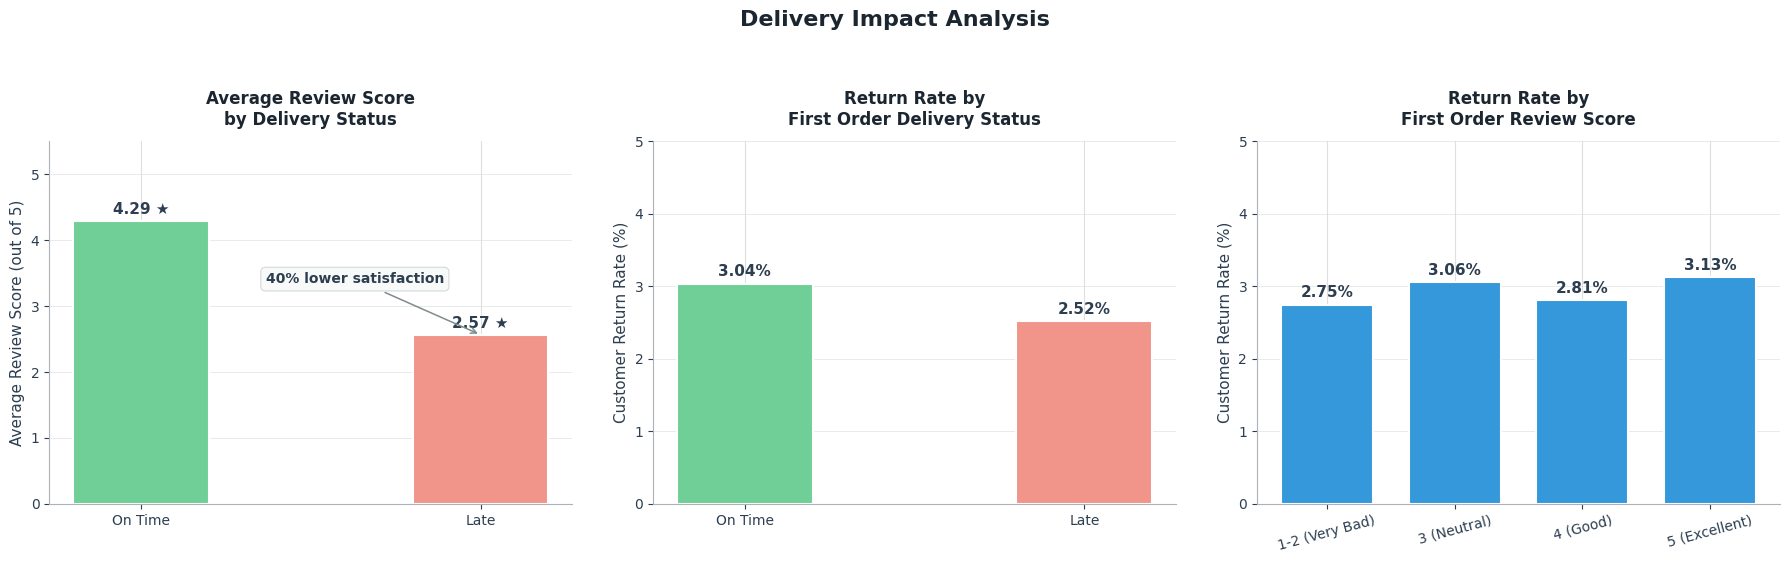

Chart saved to outputs/03_delivery_impact.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

fig.suptitle(
    'Delivery Impact Analysis',
    fontsize=16,
    fontweight='bold',
    color='#1B2631',
    y=0.98
)


TITLE_SIZE = 12
LABEL_SIZE = 11
TICK_SIZE = 10
VALUE_SIZE = 11

TEXT_COLOR = '#2C3E50'
GRID_COLOR = '#D5D8DC'

ON_TIME_COLOR = '#6FCF97'
LATE_COLOR = '#F1948A'


REVIEW_COLOR = '#3498DB'


ax1 = axes[0]

colors1 = [ON_TIME_COLOR, LATE_COLOR]

bars1 = ax1.bar(
    review_by_lateness['Delivery Status'],
    review_by_lateness['Avg Review Score'],
    color=colors1,
    width=0.4,
    edgecolor='white',
    linewidth=1.5
)

for i, (bar, val) in enumerate(
    zip(bars1, review_by_lateness['Avg Review Score'])
):
    label = f'{val:.2f} ★'

    if 'Sample Size' in review_by_lateness.columns:
        n = review_by_lateness.iloc[i]['Sample Size']
        label += f'\nn={int(n):,}'

    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.06,
        label,
        ha='center',
        va='bottom',
        fontsize=VALUE_SIZE,
        fontweight='bold',
        color=TEXT_COLOR
    )

ax1.set_title(
    'Average Review Score\nby Delivery Status',
    fontsize=TITLE_SIZE,
    fontweight='bold',
    color='#1B2631',
    pad=12
)

ax1.set_ylabel(
    'Average Review Score (out of 5)',
    fontsize=LABEL_SIZE,
    color=TEXT_COLOR
)

ax1.set_ylim(0, 5.5)

on_time_value = review_by_lateness.loc[
    review_by_lateness['Delivery Status'] == 'On Time',
    'Avg Review Score'
].iloc[0]

late_value = review_by_lateness.loc[
    review_by_lateness['Delivery Status'] == 'Late',
    'Avg Review Score'
].iloc[0]

satisfaction_drop = (
    (on_time_value - late_value) / on_time_value
) * 100

ax1.annotate(
    f'{satisfaction_drop:.0f}% lower satisfaction',
    xy=(1, late_value),
    xytext=(0.63, 3.35),
    textcoords='data',
    fontsize=10,
    fontweight='bold',
    color=TEXT_COLOR,
    ha='center',
    arrowprops=dict(
        arrowstyle='->',
        color='#7F8C8D',
        linewidth=1.1
    ),
    bbox=dict(
        boxstyle='round,pad=0.35',
        facecolor='#F8F9F9',
        edgecolor='#D5D8DC',
        linewidth=0.8
    )
)

ax2 = axes[1]

colors2 = [ON_TIME_COLOR, LATE_COLOR]

bars2 = ax2.bar(
    return_by_lateness['First Order'],
    return_by_lateness['Return Rate %'],
    color=colors2,
    width=0.4,
    edgecolor='white',
    linewidth=1.5
)

for i, (bar, val) in enumerate(
    zip(bars2, return_by_lateness['Return Rate %'])
):
    label = f'{val:.2f}%'


    if 'Sample Size' in return_by_lateness.columns:
        n = return_by_lateness.iloc[i]['Sample Size']
        label += f'\nn={int(n):,}'

    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.06,
        label,
        ha='center',
        va='bottom',
        fontsize=VALUE_SIZE,
        fontweight='bold',
        color=TEXT_COLOR
    )

ax2.set_title(
    'Return Rate by\nFirst Order Delivery Status',
    fontsize=TITLE_SIZE,
    fontweight='bold',
    color='#1B2631',
    pad=12
)

ax2.set_ylabel(
    'Customer Return Rate (%)',
    fontsize=LABEL_SIZE,
    color=TEXT_COLOR
)

ax2.set_ylim(0, 5)


ax3 = axes[2]

bars3 = ax3.bar(
    return_by_review['Review Score'],
    return_by_review['Return Rate %'],
    color=REVIEW_COLOR,
    width=0.72,
    edgecolor='white',
    linewidth=1.5
)

for i, (bar, val) in enumerate(
    zip(bars3, return_by_review['Return Rate %'])
):
    label = f'{val:.2f}%'

    if 'Sample Size' in return_by_review.columns:
        n = return_by_review.iloc[i]['Sample Size']
        label += f'\nn={int(n):,}'

    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.06,
        label,
        ha='center',
        va='bottom',
        fontsize=VALUE_SIZE,
        fontweight='bold',
        color=TEXT_COLOR
    )

ax3.set_title(
    'Return Rate by\nFirst Order Review Score',
    fontsize=TITLE_SIZE,
    fontweight='bold',
    color='#1B2631',
    pad=12
)

ax3.set_ylabel(
    'Customer Return Rate (%)',
    fontsize=LABEL_SIZE,
    color=TEXT_COLOR
)

ax3.set_ylim(0, 5)

ax3.tick_params(
    axis='x',
    rotation=15
)

for ax in axes:

    ax.grid(
        axis='y',
        linestyle='-',
        linewidth=0.7,
        color=GRID_COLOR,
        alpha=0.55
    )

    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['left'].set_color('#ABB2B9')
    ax.spines['bottom'].set_color('#ABB2B9')

    ax.tick_params(
        axis='both',
        labelsize=TICK_SIZE,
        colors=TEXT_COLOR
    )

    ax.set_facecolor('white')

plt.tight_layout(
    rect=[0, 0.05, 1, 0.93],
    w_pad=3
)

os.makedirs('outputs', exist_ok=True)

plt.savefig(
    'outputs/03_delivery_impact.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Chart saved to outputs/03_delivery_impact.png")

## Analysis 4 — Customer Segmentation (RFM)
**Business Question:** Which customers are most valuable and which are slipping away?

Using Recency and Monetary only — Frequency deliberately excluded because
97% of customers bought only once, making frequency a near-constant with no analytical value.

Snapshot date: last order date in the dataset.
Segments: Champions, At Risk, Lost.

In [18]:
# Snapshot = day after the last order in the dataset
SNAPSHOT = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {SNAPSHOT.date()}")

# Build RFM table at customer level
rfm = customer_orders.copy()
rfm['recency']  = (SNAPSHOT - rfm['last_purchase']).dt.days
rfm['monetary'] = rfm['total_spent']

# Score Recency: lower days = higher score (4 = most recent)
rfm['R_score'] = pd.qcut(rfm['recency'],  q=4, labels=[4, 3, 2, 1]).astype(int)

# Score Monetary: higher spend = higher score
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                          q=4, labels=[1, 2, 3, 4]).astype(int)

# Segment using R and M scores
def assign_segment(row):
    if row['R_score'] >= 3 and row['M_score'] >= 3:
        return 'Champions'
    elif row['R_score'] >= 2 and row['M_score'] >= 2:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Segment summary
seg_summary = rfm.groupby('Segment').agg(
    customers      = ('customer_unique_id', 'count'),
    avg_recency    = ('recency', 'mean'),
    avg_monetary   = ('monetary', 'mean'),
    total_revenue  = ('monetary', 'sum')
).round(1).reset_index()

seg_summary['pct_customers'] = (seg_summary['customers'] /
                                  seg_summary['customers'].sum() * 100).round(1)
seg_summary['pct_revenue']   = (seg_summary['total_revenue'] /
                                  seg_summary['total_revenue'].sum() * 100).round(1)

print("\nCustomer Segmentation Summary:")
print(seg_summary.to_string(index=False))

Snapshot date: 2018-08-30

Customer Segmentation Summary:
  Segment  customers  avg_recency  avg_monetary  total_revenue  pct_customers  pct_revenue
  At Risk      28770        212.7         155.5      4474774.6           30.8         29.0
Champions      23917        112.0         266.0      6360902.1           25.6         41.3
     Lost      40663        329.9         112.7      4582718.2           43.6         29.7


### Segmentation Visualisation

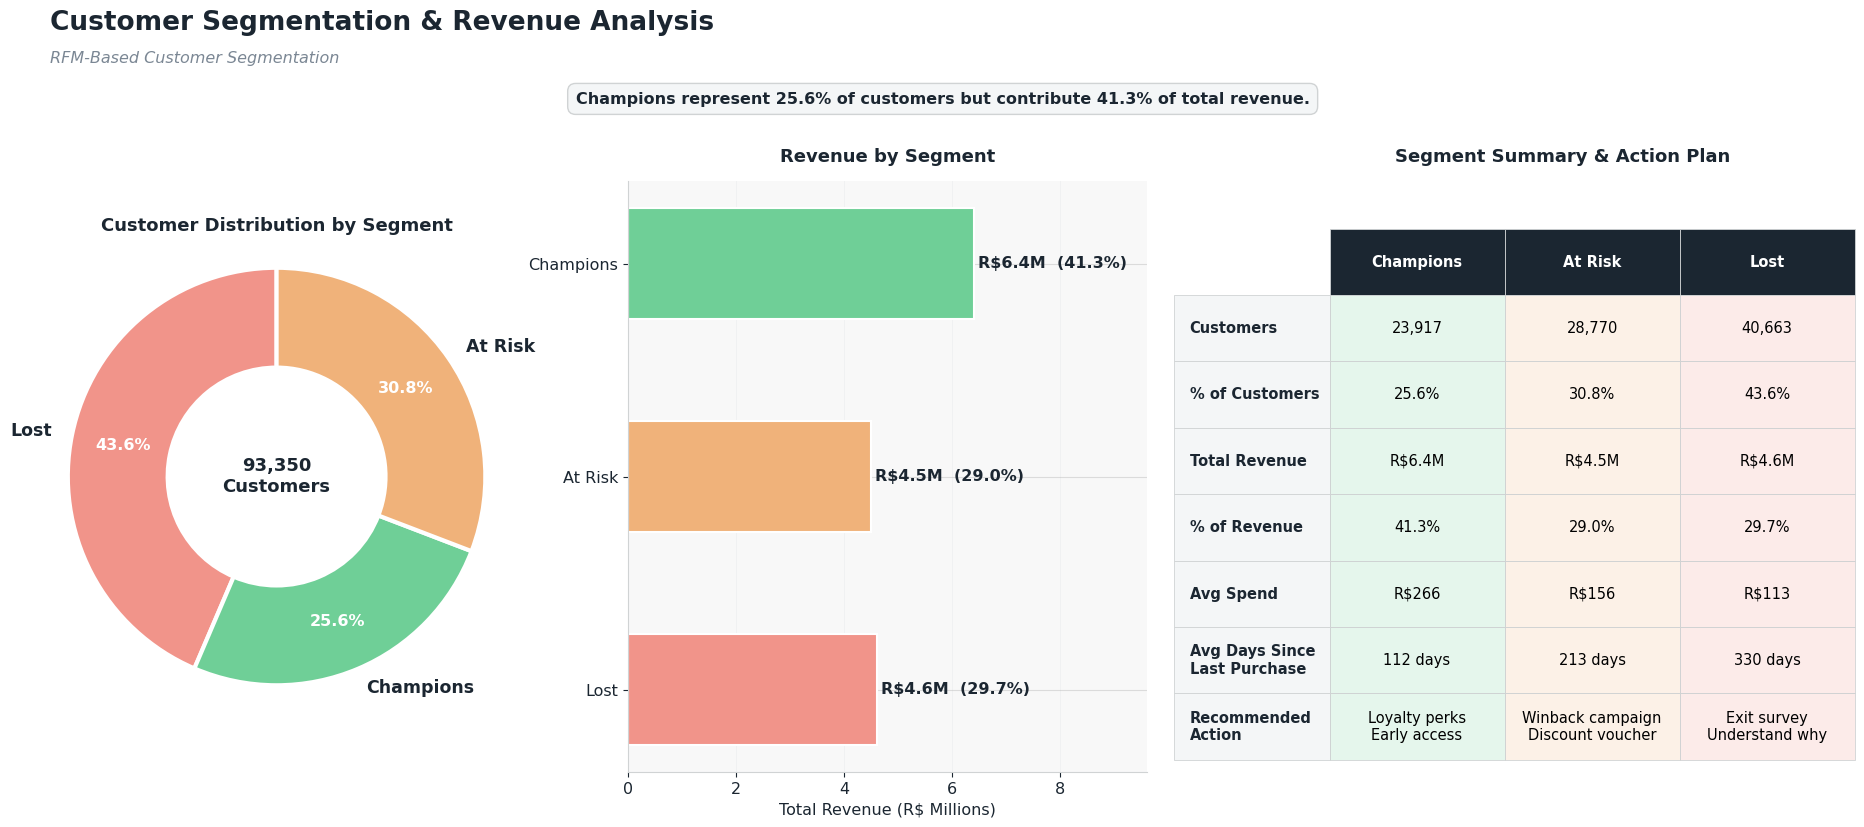

Chart saved to outputs/05_customer_segments.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import os

seg_summary = pd.DataFrame({
    'Segment':        ['Lost', 'Champions', 'At Risk'],
    'customers':       [40663, 23917, 28770],
    'pct_customers':   [43.6, 25.6, 30.8],
    'total_revenue':   [4.6e6, 6.4e6, 4.5e6],
    'pct_revenue':     [29.7, 41.3, 29.0],
    'avg_monetary':    [113, 266, 156],
    'avg_recency':     [330, 112, 213],
})

seg_colors = {
    'Champions': '#6FCF97',
    'At Risk': '#F0B27A',
    'Lost': '#F1948A'
}

colors_ordered = [seg_colors[s] for s in seg_summary['Segment']]


fig = plt.figure(figsize=(19, 8.2))

gs = gridspec.GridSpec(
    1, 3,


    width_ratios=[1.05, 1.20, 1.35],


    wspace=0.24,

    left=0.03,
    right=0.98,
    top=0.78,
    bottom=0.06
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])


fig.text(
    0.03, 0.965,
    'Customer Segmentation & Revenue Analysis',
    fontsize=19,
    fontweight='bold',
    color='#1B2631',
    ha='left'
)

fig.text(
    0.03, 0.925,
    'RFM-Based Customer Segmentation',
    fontsize=11.5,
    color='#7B8794',
    ha='left',
    style='italic'
)

fig.text(
    0.5, 0.875,
    'Champions represent 25.6% of customers but contribute 41.3% of total revenue.',
    fontsize=11.5,
    fontweight='bold',
    color='#1B2631',
    ha='center',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='#F4F6F7',
        edgecolor='#D0D3D4',
        linewidth=1
    )
)

# ── LEFT: Donut Chart — Customer Distribution ───────────────────────────────
wedges, texts, autotexts = ax1.pie(
    seg_summary['customers'],
    labels=seg_summary['Segment'],
    colors=colors_ordered,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 3,
        'width': 0.55
    },
    radius=1.15
)

for text in texts:
    text.set_fontsize(12.5)
    text.set_fontweight('bold')
    text.set_color('#1B2631')

for autotext in autotexts:
    autotext.set_fontsize(11.5)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Centre text
ax1.text(
    0, 0,
    '93,350\nCustomers',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold',
    color='#1B2631'
)

ax1.set_title(
    'Customer Distribution by Segment',
    fontsize=13,
    fontweight='bold',
    color='#1B2631',
    pad=14
)

# ── MIDDLE: Horizontal Bar — Revenue by Segment ─────────────────────────────
bar_order = ['Lost', 'At Risk', 'Champions']

seg_bar = (
    seg_summary
    .set_index('Segment')
    .loc[bar_order]
    .reset_index()
)

bar_colors = [seg_colors[s] for s in seg_bar['Segment']]

bars = ax2.barh(
    seg_bar['Segment'],
    seg_bar['total_revenue'] / 1e6,
    color=bar_colors,
    edgecolor='white',
    linewidth=1.5,
    height=0.52
)

for bar, row in zip(bars, seg_bar.itertuples()):
    ax2.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f'R${row.total_revenue / 1e6:.1f}M  ({row.pct_revenue}%)',
        va='center',
        fontsize=11.5,
        fontweight='bold',
        color='#1B2631'
    )

ax2.set_xlabel(
    'Total Revenue (R$ Millions)',
    fontsize=11.5,
    color='#1B2631'
)

ax2.set_title(
    'Revenue by Segment',
    fontsize=13,
    fontweight='bold',
    color='#1B2631',
    pad=14
)

ax2.set_xlim(
    0,
    seg_summary['total_revenue'].max() / 1e6 * 1.5
)

ax2.tick_params(
    axis='both',
    labelsize=11.5,
    colors='#1B2631'
)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#D0D3D4')
ax2.spines['bottom'].set_color('#D0D3D4')

ax2.grid(
    axis='x',
    color='#E5E7E9',
    linewidth=0.7,
    zorder=0
)

ax2.set_axisbelow(True)

# ── RIGHT: Summary Table ─────────────────────────────────────────────────────
ax3.axis('off')

table_data = [
    ['Metric', 'Champions', 'At Risk', 'Lost'],

    ['Customers',
     f"{seg_summary.loc[seg_summary['Segment'] == 'Champions', 'customers'].values[0]:,}",
     f"{seg_summary.loc[seg_summary['Segment'] == 'At Risk', 'customers'].values[0]:,}",
     f"{seg_summary.loc[seg_summary['Segment'] == 'Lost', 'customers'].values[0]:,}"],

    ['% of Customers',
     f"{seg_summary.loc[seg_summary['Segment'] == 'Champions', 'pct_customers'].values[0]}%",
     f"{seg_summary.loc[seg_summary['Segment'] == 'At Risk', 'pct_customers'].values[0]}%",
     f"{seg_summary.loc[seg_summary['Segment'] == 'Lost', 'pct_customers'].values[0]}%"],

    ['Total Revenue',
     f"R${seg_summary.loc[seg_summary['Segment'] == 'Champions', 'total_revenue'].values[0] / 1e6:.1f}M",
     f"R${seg_summary.loc[seg_summary['Segment'] == 'At Risk', 'total_revenue'].values[0] / 1e6:.1f}M",
     f"R${seg_summary.loc[seg_summary['Segment'] == 'Lost', 'total_revenue'].values[0] / 1e6:.1f}M"],

    ['% of Revenue',
     f"{seg_summary.loc[seg_summary['Segment'] == 'Champions', 'pct_revenue'].values[0]}%",
     f"{seg_summary.loc[seg_summary['Segment'] == 'At Risk', 'pct_revenue'].values[0]}%",
     f"{seg_summary.loc[seg_summary['Segment'] == 'Lost', 'pct_revenue'].values[0]}%"],

    ['Avg Spend',
     f"R${seg_summary.loc[seg_summary['Segment'] == 'Champions', 'avg_monetary'].values[0]:.0f}",
     f"R${seg_summary.loc[seg_summary['Segment'] == 'At Risk', 'avg_monetary'].values[0]:.0f}",
     f"R${seg_summary.loc[seg_summary['Segment'] == 'Lost', 'avg_monetary'].values[0]:.0f}"],

    ['Avg Days Since\nLast Purchase',
     f"{seg_summary.loc[seg_summary['Segment'] == 'Champions', 'avg_recency'].values[0]:.0f} days",
     f"{seg_summary.loc[seg_summary['Segment'] == 'At Risk', 'avg_recency'].values[0]:.0f} days",
     f"{seg_summary.loc[seg_summary['Segment'] == 'Lost', 'avg_recency'].values[0]:.0f} days"],

    ['Recommended\nAction',
     'Loyalty perks\nEarly access',
     'Winback campaign\nDiscount voucher',
     'Exit survey\nUnderstand why'],
]

tbl = ax3.table(
    cellText=[row[1:] for row in table_data[1:]],
    rowLabels=[row[0] for row in table_data[1:]],
    colLabels=table_data[0][1:],
    cellLoc='center',
    rowLoc='left',
    loc='center',

    # Small inward shift to prevent table labels from approaching bar chart
    bbox=[0.10, 0.02, 0.90, 0.90]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)

# ── Style header row ─────────────────────────────────────────────────────────
for col in range(3):
    tbl[(0, col)].set_facecolor('#1B2631')
    tbl[(0, col)].set_text_props(
        color='white',
        fontweight='bold'
    )

# ── Style segment columns using same muted palette ──────────────────────────
col_fill = {
    0: seg_colors['Champions'],
    1: seg_colors['At Risk'],
    2: seg_colors['Lost']
}

for row in range(1, len(table_data)):
    for col, base in col_fill.items():
        tbl[(row, col)].set_facecolor(base + '2E')

# ── Style row labels ─────────────────────────────────────────────────────────
for row in range(len(table_data) - 1):
    tbl.get_celld()[(row + 1, -1)].set_facecolor('#F4F6F7')
    tbl.get_celld()[(row + 1, -1)].set_text_props(
        fontweight='bold',
        color='#1B2631'
    )

# ── Table borders / row heights ──────────────────────────────────────────────
for key, cell in tbl.get_celld().items():
    cell.set_edgecolor('#D0D3D4')
    cell.set_linewidth(0.6)
    cell.set_height(cell.get_height() * 1.18)

ax3.set_title(
    'Segment Summary & Action Plan',
    fontsize=13,
    fontweight='bold',
    color='#1B2631',
    pad=14
)

# ── Save output ──────────────────────────────────────────────────────────────
os.makedirs('outputs', exist_ok=True)

plt.savefig(
    'outputs/05_customer_segments.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Chart saved to outputs/05_customer_segments.png")

## Analysis 5 — Business Recommendations

Based on the analysis of 96,470 delivered orders across 93,350 unique customers.

---

### Finding 1 — The platform has a severe retention crisis
**97% of customers never return after their first purchase.**
Only 2,801 out of 93,350 customers placed a second order.
This is not a churn problem — it is an activation problem.
The business is spending acquisition budget to bring in customers who use the platform once and leave.

**Recommendation:** Introduce a post-purchase re-engagement sequence — a targeted discount
voucher sent 7 days after the first delivery to incentivise a second purchase.
Even moving the return rate from 3% to 5% would add approximately 1,860 new repeat customers.

---

### Finding 2 — Late deliveries cause a 40% drop in satisfaction
**On-time orders average 4.29 stars. Late orders average 2.57 stars.**
7,826 orders (8.1% of all delivered orders) arrived after the estimated delivery date.
Late delivery is the single biggest driver of poor customer experience.

**Recommendation:** Enforce stricter SLA agreements with logistics partners.
Priority fix should target the states with the highest late delivery rates.
Improving on-time delivery from 91.9% to 95% would save approximately 3,000 customers
per year from a bad first experience.

---

### Finding 3 — Revenue is growing strongly but seasonally concentrated
**Revenue grew 9x from R$127K in January 2017 to R$1.15M in November 2017.**
November 2017 (Black Friday) was the single highest revenue month.
Monday is consistently the highest revenue day — weekday purchasing dominates.

**Recommendation:** Plan inventory and logistics capacity 6–8 weeks before November
to handle the Black Friday surge without increasing late deliveries.
Run marketing campaigns on Monday–Wednesday, not weekends when purchase intent is lowest.

---

### Finding 4 — Champions are a small group driving outsized revenue
**Champions are 25.6% of customers but generate 41.3% of total revenue.**
Average Champion spends R$266 versus R$113 for Lost customers.
At Risk customers (30.8% of base) have not purchased in 213 days on average —
they are slipping toward Lost but are still recoverable.

**Recommendation:** Launch a tiered retention strategy:
- **Champions** — loyalty programme, early access to new products, free shipping threshold
- **At Risk** — personalised winback email with 10–15% discount voucher within 30 days
- **Lost** — exit survey to understand reasons for leaving; low-cost intervention only

## Project Summary — Key Numbers
A single-cell summary of every headline finding for quick reference.

In [20]:
print("=" * 60)
print("  OLIST E-COMMERCE ANALYSIS — KEY FINDINGS SUMMARY")
print("=" * 60)

print(f"""
DATASET
  Total orders loaded:         99,441
  Delivered orders analysed:   {len(df_clean):,}
  Unique customers:            {len(customer_orders):,}

CUSTOMER JOURNEY
  Never returned after 1st:    {never_returned:,} ({never_return_pct:.1f}%)
  Returned for 2nd purchase:   {returned_2nd:,} ({returned_2nd/total_customers*100:.1f}%)
  Loyal customers (4+ orders): {loyal:,} ({loyal/total_customers*100:.1f}%)

SALES TRENDS
  Best month:                  Nov 2017 — R$1,153,229 (Black Friday)
  Worst month:                 Jan 2017 — R$127,482
  Revenue growth (14 months):  ~9x
  Strongest day:               Monday (R$2,530,094 total)
  Weakest day:                 Saturday (R$1,705,803 total)

DELIVERY IMPACT
  Avg delivery time:           {df_clean['days_to_deliver'].mean():.1f} days
  Late deliveries:             {df_clean['is_late'].sum():,} ({df_clean['is_late'].mean()*100:.1f}%)
  Avg review — on time:        {ontime_score:.2f} / 5
  Avg review — late:           {late_score:.2f} / 5
  Satisfaction drop:           {ontime_score - late_score:.2f} points ({(ontime_score-late_score)/ontime_score*100:.1f}%)

CUSTOMER SEGMENTS
  Champions:  {seg_val('customers','Champions'):,} customers ({seg_val('pct_customers','Champions')}%)  →  R${seg_val('total_revenue','Champions')/1e6:.1f}M ({seg_val('pct_revenue','Champions')}% of revenue)
  At Risk:    {seg_val('customers','At Risk'):,} customers ({seg_val('pct_customers','At Risk')}%)  →  R${seg_val('total_revenue','At Risk')/1e6:.1f}M ({seg_val('pct_revenue','At Risk')}% of revenue)
  Lost:       {seg_val('customers','Lost'):,} customers ({seg_val('pct_customers','Lost')}%)  →  R${seg_val('total_revenue','Lost')/1e6:.1f}M ({seg_val('pct_revenue','Lost')}% of revenue)
  Avg spend — Champions: R${seg_val('avg_monetary','Champions'):.0f}
  Avg spend — Lost:      R${seg_val('avg_monetary','Lost'):.0f}
""")
print("=" * 60)
print("  4 charts saved to output/ folder")
print("  analysis.ipynb — complete")
print("=" * 60)

  OLIST E-COMMERCE ANALYSIS — KEY FINDINGS SUMMARY


NameError: name 'seg_val' is not defined

In [ ]:
pip install pandas sqlalchemy pymysql

In [ ]:
import pandas as pd
import os

from sqlalchemy import create_engine

In [ ]:
import os
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

# ============================================================
# 1. FOLDER CONTAINING ALL CSV FILES
# ============================================================

folder_path = r"C:\Users\Aman Singh\OneDrive\Desktop\PROJECT\data"


# ============================================================
# 2. MYSQL DETAILS
# ============================================================

mysql_user = "root"
mysql_password = "Aman@1234"   # <-- Change this
mysql_host = "localhost"
mysql_port = 3307

# Name of the database you want to use
database_name = "olist"


# ============================================================
# 3. CONNECT TO MYSQL SERVER
# ============================================================

server_url = URL.create(
    drivername="mysql+pymysql",
    username=mysql_user,
    password=mysql_password,
    host=mysql_host,
    port=mysql_port
)

server_engine = create_engine(server_url)


# ============================================================
# 4. CREATE DATABASE IF IT DOESN'T EXIST
# ============================================================

with server_engine.connect() as connection:
    connection.exec_driver_sql(
        f"CREATE DATABASE IF NOT EXISTS `{database_name}`"
    )

print(f"Database '{database_name}' is ready.")


# ============================================================
# 5. CONNECT TO THE DATABASE
# ============================================================

database_url = URL.create(
    drivername="mysql+pymysql",
    username=mysql_user,
    password=mysql_password,
    host=mysql_host,
    port=mysql_port,
    database=database_name
)

engine = create_engine(database_url)


# ============================================================
# 6. FIND AND IMPORT ALL CSV FILES
# ============================================================

csv_files = [
    file for file in os.listdir(folder_path)
    if file.lower().endswith(".csv")
]

print(f"\nFound {len(csv_files)} CSV files.\n")


for file in csv_files:

    file_path = os.path.join(folder_path, file)

    # File name becomes table name
    table_name = os.path.splitext(file)[0]

    # Clean table name slightly
    table_name = (
        table_name
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    print(f"Importing: {file}")
    print(f"Table name: {table_name}")

    try:
        # Read CSV
        df = pd.read_csv(file_path)

        # Clean column names
        df.columns = (
            df.columns
            .str.strip()
            .str.lower()
            .str.replace(" ", "_")
            .str.replace("-", "_")
        )

        # Upload to MySQL
        df.to_sql(
            name=table_name,
            con=engine,
            if_exists="replace",
            index=False,
            chunksize=1000
        )

        print(f"Successfully imported {len(df)} rows.\n")

    except Exception as e:
        print(f"Error importing {file}:")
        print(e)
        print()


# ============================================================
# 7. FINISHED
# ============================================================

print("=" * 50)
print("IMPORT COMPLETED")
print("=" * 50)

engine.dispose()

In [21]:
# Export 1: Master orders data (for sales trend and delivery analysis)
df_clean[[
    'order_id', 'customer_unique_id', 'customer_state',
    'order_purchase_timestamp', 'total_value', 'n_items',
    'days_to_deliver', 'is_late', 'days_late',
    'review_score', 'purchase_month', 'purchase_year', 'day_of_week'
]].to_csv('output/powerbi_orders.csv', index=False)

# Export 2: Customer segmentation data
rfm[[
    'customer_unique_id', 'total_orders', 'total_spent',
    'recency', 'monetary', 'R_score', 'M_score', 'Segment'
]].to_csv('output/powerbi_segments.csv', index=False)

# Export 3: Monthly revenue summary
monthly_revenue.to_csv('output/powerbi_monthly_revenue.csv', index=False)

# Export 4: Segment summary (for KPI cards and charts)
seg_summary.to_csv('output/powerbi_seg_summary.csv', index=False)

print("Exports complete. Files saved to output/ folder:")
print("  powerbi_orders.csv")
print("  powerbi_segments.csv")
print("  powerbi_monthly_revenue.csv")
print("  powerbi_seg_summary.csv")

# Quick check
import os
for f in os.listdir('output'):
    if f.startswith('powerbi'):
        size = os.path.getsize(f'output/{f}')
        print(f"  {f}: {size:,} bytes")

Exports complete. Files saved to output/ folder:
  powerbi_orders.csv
  powerbi_segments.csv
  powerbi_monthly_revenue.csv
  powerbi_seg_summary.csv
  powerbi_monthly_revenue.csv: 413 bytes
  powerbi_orders.csv: 13,357,525 bytes
  powerbi_segments.csv: 6,407,023 bytes
  powerbi_seg_summary.csv: 212 bytes


In [1]:
# Re-export monthly revenue with month as plain string
monthly_revenue_pbi = monthly_revenue.copy()
monthly_revenue_pbi['purchase_month'] = monthly_revenue_pbi['purchase_month'].astype(str)
monthly_revenue_pbi.to_csv('output/powerbi_monthly_revenue.csv', index=False)
print("Re-exported. Sample:")
print(monthly_revenue_pbi.head(3))

NameError: name 'monthly_revenue' is not defined